In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime, timedelta
import requests

# Aluminium

In [2]:
import json

# https://www.lme.com/api/trading-data/chart-data?datasourceId=37cf78d1-222d-4618-b9f4-c5f13ff421e6&startDate=2020-04-07&endDate=2025-04-04

with open('data_aluminium') as f:
    d = json.load(f)
    #print(d)

In [3]:
df = pd.DataFrame({'time' : pd.to_datetime(d['Labels'], format = "%d/%m/%Y"), 
                  'price' : d['Datasets'][0]['Data']})
df['price'] = df['price'].astype(float)
df.head()

,time,price
0,2020-04-07,1477.5
1,2020-04-08,1465.5
2,2020-04-09,1479.5
3,2020-04-14,1503.5
4,2020-04-15,1507.5


<Axes: xlabel='time'>

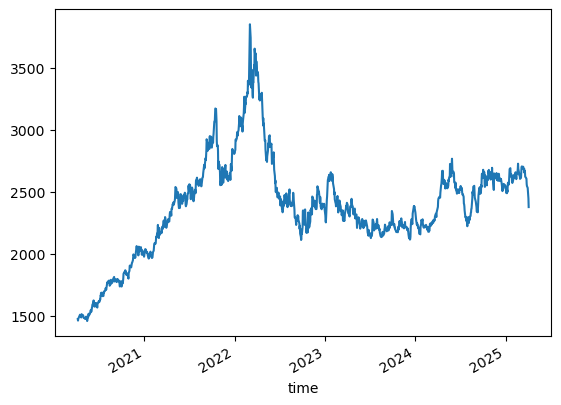

In [4]:
df.set_index('time').price.plot()

In [5]:
(df.price.max()-df.price.min())/df.price.mean()

np.float64(1.0013704771053473)

In [ ]:
df['Aluminium index'] = df['price']/df['price'].iloc[0]

# Nickel

In [17]:
import json

# https://www.lme.com/api/trading-data/chart-data?datasourceId=37cf78d1-222d-4618-b9f4-c5f13ff421e6&startDate=2020-04-07&endDate=2025-04-04

with open('data_nickel') as f:
    d2 = json.load(f)
    #print(d)

In [18]:
df_nickel = pd.DataFrame({'time' : pd.to_datetime(d2['Labels'], format = "%d/%m/%Y"), 
                  'price' : d2['Datasets'][2]['Data']})
df_nickel['price'] = df_nickel['price'].astype(float)
df_nickel.head()

,time,price
0,2020-04-07,11409.0
1,2020-04-08,11497.0
2,2020-04-09,11523.0
3,2020-04-14,11803.0
4,2020-04-15,11795.0


Text(0.5, 1.0, 'historische Nikkelprijs')

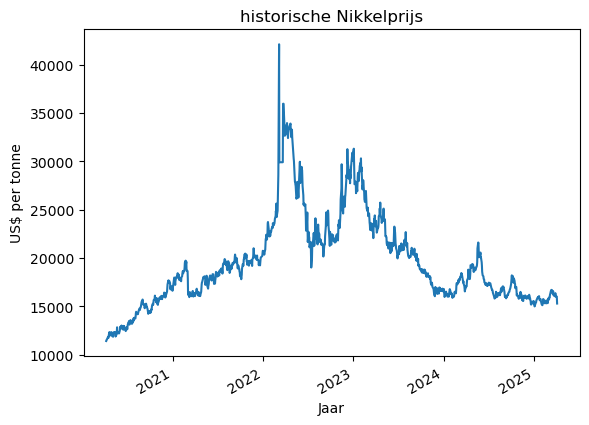

In [19]:
ax = df_nickel.set_index('time').price.plot()
ax.set_ylabel("US$ per tonne")
ax.set_xlabel("Jaar")
ax.set_title('historische Nikkelprijs')

In [20]:
df_nickel.price.mean()

np.float64(19467.1165741475)

In [21]:
(df_nickel.price.max()-df_nickel.price.min())/df_nickel.price.mean()

np.float64(1.5765560288860607)

# Staal

In [22]:
#https://www.lme.com/api/trading-data/chart-data?datasourceId=2d71123c-0e03-4995-bf85-cd9c897199eb&startDate=2020-04-07&endDate=2025-04-04
with open('data_steel') as f:
    d3 = json.load(f)
    #print(d)

In [23]:
df_steel = pd.DataFrame({'time' : pd.to_datetime(d3['Labels'], format = "%d/%m/%Y"), 
                  'price' : d3['Datasets'][2]['Data']})
df_steel['price'] = df_steel['price'].astype(float)
df_steel = df_steel.loc[lambda d: d.price > 0].copy()
df_steel.head()

,time,price
327,2021-07-27,1385.5
328,2021-07-28,1380.5
329,2021-07-29,1376.0
330,2021-07-30,1370.5
331,2021-08-02,1371.5


<Axes: xlabel='time'>

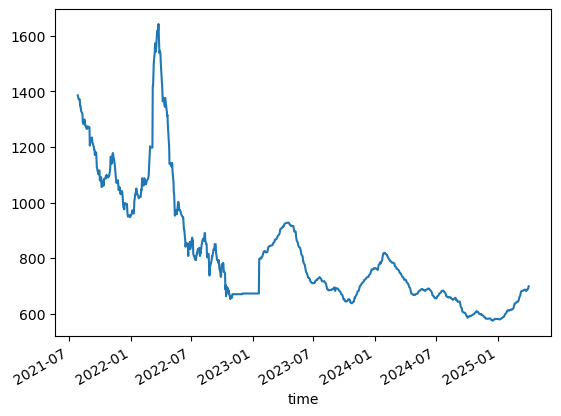

In [24]:
df_steel.set_index('time').price.plot()

In [25]:
(df_steel.price.max()-df_steel.price.min())/df_steel.price.mean()

np.float64(1.3023712625686052)

# Eurostat API

|Material |	NACE Rev.2 Code |
|-----------|----------------|
|basic iron and steel	|C24.1|
|Textile	|C13|
|Leather	|C15|
|Plastic	|C22.2 (subdivisions C22.21–C22.29)|
|Wood	|C16|
|Aluminium | C2442|


In [4]:
def parse_json(json):
    values = pd.DataFrame({'key' : json['value'].keys(),
                 'value' : json['value'].values()})
    values['key'] = pd.to_numeric(values['key'])
    time = pd.DataFrame({'Jaar' : json['dimension']['time']['category']['index'].keys(),
                         'key' : json['dimension']['time']['category']['index'].values()})
    time['key'] = pd.to_numeric(time['key'])
    df = values.merge(time, how = 'left')
    return df

def get_eurostat_data(code):

    ppi_url = (
        "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/STS_INPP_M"
    #    "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/STS_INPI_M"
        "?lang=EN"
        f"&nace_r2={code}"        # Leather & related products
        "&geo=EU27_2020"      # EU-27 aggregate
        "&unit=I21"           # Index, 2021=100
        "&s_adj=NSA"          # Not seasonally adjusted
        "&sinceTimePeriod=2015"
    )
    
    ppi_resp = requests.get(ppi_url)
    ppi_json = ppi_resp.json()
    df = parse_json(ppi_json)
    df['Jaar'] = pd.to_datetime(df['Jaar'], format = '%Y-%m')
    df['value'] = df['value']/df['value'].iloc[0]
    return df.set_index('Jaar').value.rename(code)



In [5]:
#ppi_json

In [8]:
prijzen = []

for code in ['C13','C25' ,'C15', 'C2221', 'C1395','C2016']:
    prijzen.append(get_eurostat_data(code))
    

<Axes: xlabel='Jaar'>

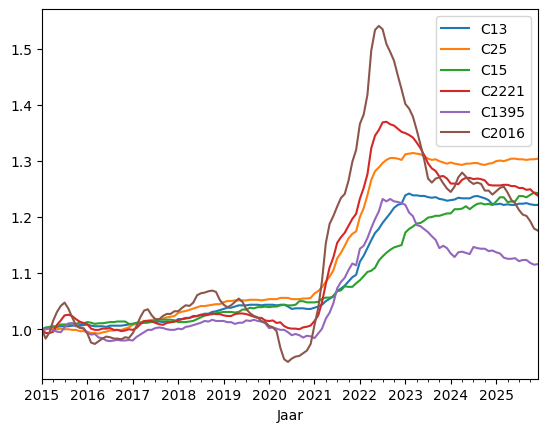

In [13]:
pd.concat(prijzen, axis=1).to_excel('eurostat_prijzen.xlsx')
pd.concat(prijzen, axis=1).plot()

In [6]:
test = get_eurostat_data('C15')

Text(0, 0.5, 'Import Price Index (PPI)')

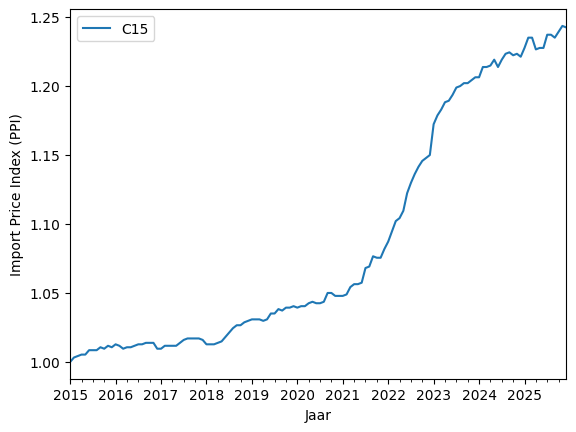

In [7]:
ax = test.plot(legend = True)
ax.set_ylabel("Import Price Index (PPI)")

## add FRED data

In [72]:
steel = pd.read_excel('FRED data/WPU101.xlsx', sheet_name='Monthly').rename(columns = {'observation_date' : 'Jaar', 'WPU101' : 'Staal'})
steel['Jaar'] =  pd.to_datetime(steel['Jaar'], format = '%Y-%m')

In [77]:
staal = steel.set_index('Jaar').loc['2015-01-01':]/steel.set_index('Jaar').loc['2015-01-01':].iloc[0]

In [91]:
staal

,Staal
Jaar,
2015-01-01,1.000000
2015-02-01,0.940647
2015-03-01,0.922662
2015-04-01,0.903327
2015-05-01,0.891637
...,...
2025-04-01,1.441736
2025-05-01,1.500463
2025-06-01,1.441470


In [81]:
pcu = pd.read_excel('FRED data/PCU32615032615041.xlsx', sheet_name='Monthly').rename(columns = {'observation_date' : 'Jaar', 'PCU32615032615041' : 'PCU'})
pcu['Jaar'] =  pd.to_datetime(pcu['Jaar'], format = '%Y-%m')

In [84]:
pcu = pcu.set_index('Jaar').loc['2015-01-01':]/pcu.set_index('Jaar').loc['2015-01-01':].iloc[0]

In [85]:
pcu

,PCU
Jaar,
2015-01-01,1.000000
2015-02-01,0.991138
2015-03-01,0.995910
2015-04-01,0.989775
2015-05-01,0.991138
...,...
2025-04-01,1.086183
2025-05-01,1.086183
2025-06-01,1.086183


In [95]:
katoen = pd.read_excel('FRED data/PCOTTINDUSDM.xlsx', sheet_name='Monthly').rename(columns = {'observation_date' : 'Jaar', 'PCOTTINDUSDM' : 'Katoen'})
katoen['Jaar'] =  pd.to_datetime(katoen['Jaar'], format = '%Y-%m')
katoen = katoen.set_index('Jaar').loc['2015-01-01':]/katoen.set_index('Jaar').loc['2015-01-01':].iloc[0]

In [99]:
wol = pd.read_excel('FRED data/PWOOLFUSDM.xlsx', sheet_name='Monthly').rename(columns = {'observation_date' : 'Jaar', 'PWOOLFUSDM' : 'Wol'})
wol['Jaar'] =  pd.to_datetime(wol['Jaar'], format = '%Y-%m')
wol = wol.set_index('Jaar').loc['2015-01-01':]/wol.set_index('Jaar').loc['2015-01-01':].iloc[0]

## alles samenvoegen

In [ ]:
prijzen = pd.concat([textiel, metaal, leer, plastic, aluminium, staal, pcu, katoen, wol], axis = 1)
prijzen.head()

,Textiel,Metaal,Leer,Plastic,Hout,Aluminium,Staal,PCU,Katoen,Wol
Jaar,,,,,,,,,,
2015-01-01,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000
2015-02-01,1.001065,0.988620,1.003191,0.994606,0.99877,1.018973,0.940647,0.991138,1.037008,0.979195
2015-03-01,1.003195,0.984353,1.004255,0.993528,0.99754,1.023438,0.922662,0.995910,1.029729,0.961140
2015-04-01,1.003195,0.982930,1.005319,0.994606,0.99754,1.029018,0.903327,0.989775,1.064625,1.027613
2015-05-01,1.004260,0.981508,1.005319,1.001079,0.99877,1.031250,0.891637,0.991138,1.081858,1.152580


<Axes: xlabel='Jaar'>

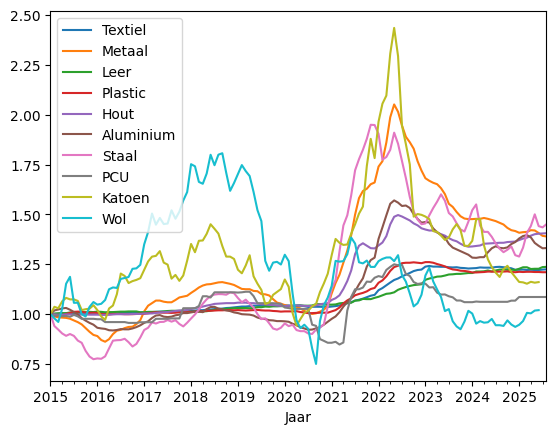

In [101]:
prijzen.plot()

<Axes: xlabel='Jaar'>

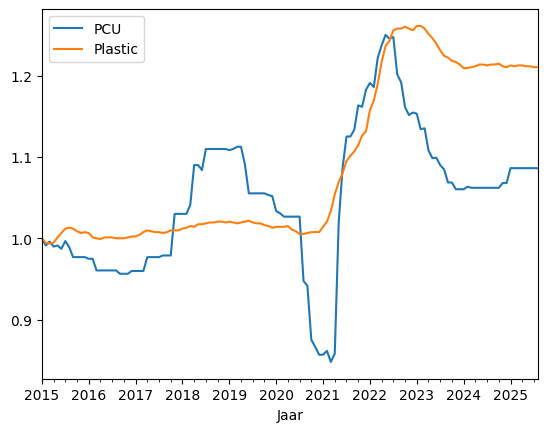

In [104]:
prijzen[['PCU','Plastic']].plot()

In [102]:
prijzen.to_excel('prijzen.xlsx')

In [3]:
prijzen = pd.read_excel('prijzen.xlsx')
prijzen

,Jaar,Textiel,Metaal,Leer,Plastic,Hout,Aluminium,Staal,PCU,Katoen,Wol
0,2015-01-01,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,2015-02-01,1.001065,0.988620,1.003191,0.994606,0.998770,1.018973,0.940647,0.991138,1.037008,0.979195
2,2015-03-01,1.003195,0.984353,1.004255,0.993528,0.997540,1.023438,0.922662,0.995910,1.029729,0.961140
3,2015-04-01,1.003195,0.982930,1.005319,0.994606,0.997540,1.029018,0.903327,0.989775,1.064625,1.027613
4,2015-05-01,1.004260,0.981508,1.005319,1.001079,0.998770,1.031250,0.891637,0.991138,1.081858,1.152580
...,...,...,...,...,...,...,...,...,...,...,...
123,2025-04-01,1.222577,1.421053,1.226596,1.212513,1.393604,1.385045,1.441736,1.086183,1.162314,1.004201
124,2025-05-01,1.221512,1.419630,1.227660,1.211435,1.400984,1.357143,1.500463,1.086183,1.157960,1.018135
125,2025-06-01,1.221512,1.406828,1.227660,1.211435,1.403444,1.342634,1.441470,1.086183,1.160957,1.020303
126,2025-07-01,1.223642,1.392603,1.236170,1.210356,1.404674,1.330357,1.435049,1.086183,NaN,NaN


In [8]:
prijzen.drop('Jaar', axis = 1).std().rename('risk2').reset_index()

,index,risk2
0,Textiel,0.093722
1,Metaal,0.300616
2,Leer,0.081999
3,Plastic,0.101074
4,Hout,0.178138
5,Aluminium,0.203580
6,Staal,0.326169
7,PCU,0.085743
8,Katoen,0.280161
9,Wol,0.258580
